<a href="https://colab.research.google.com/github/Jason-Gitau/system-design-with-python/blob/main/payment%20services/simple%20payment%20system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install diagrams

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 31.5 MB/s eta 0:00:00
  Attempting uninstall: graphviz
    Found existing installation: graphviz 0.21
    Uninstalling graphviz-0.21:
      Successfully uninstalled graphviz-0.21


In [ ]:
import os
os.listdir(".")  # lists all files in current directory

['.config', 'simple_payment_backend_system.png', 'sample_data']

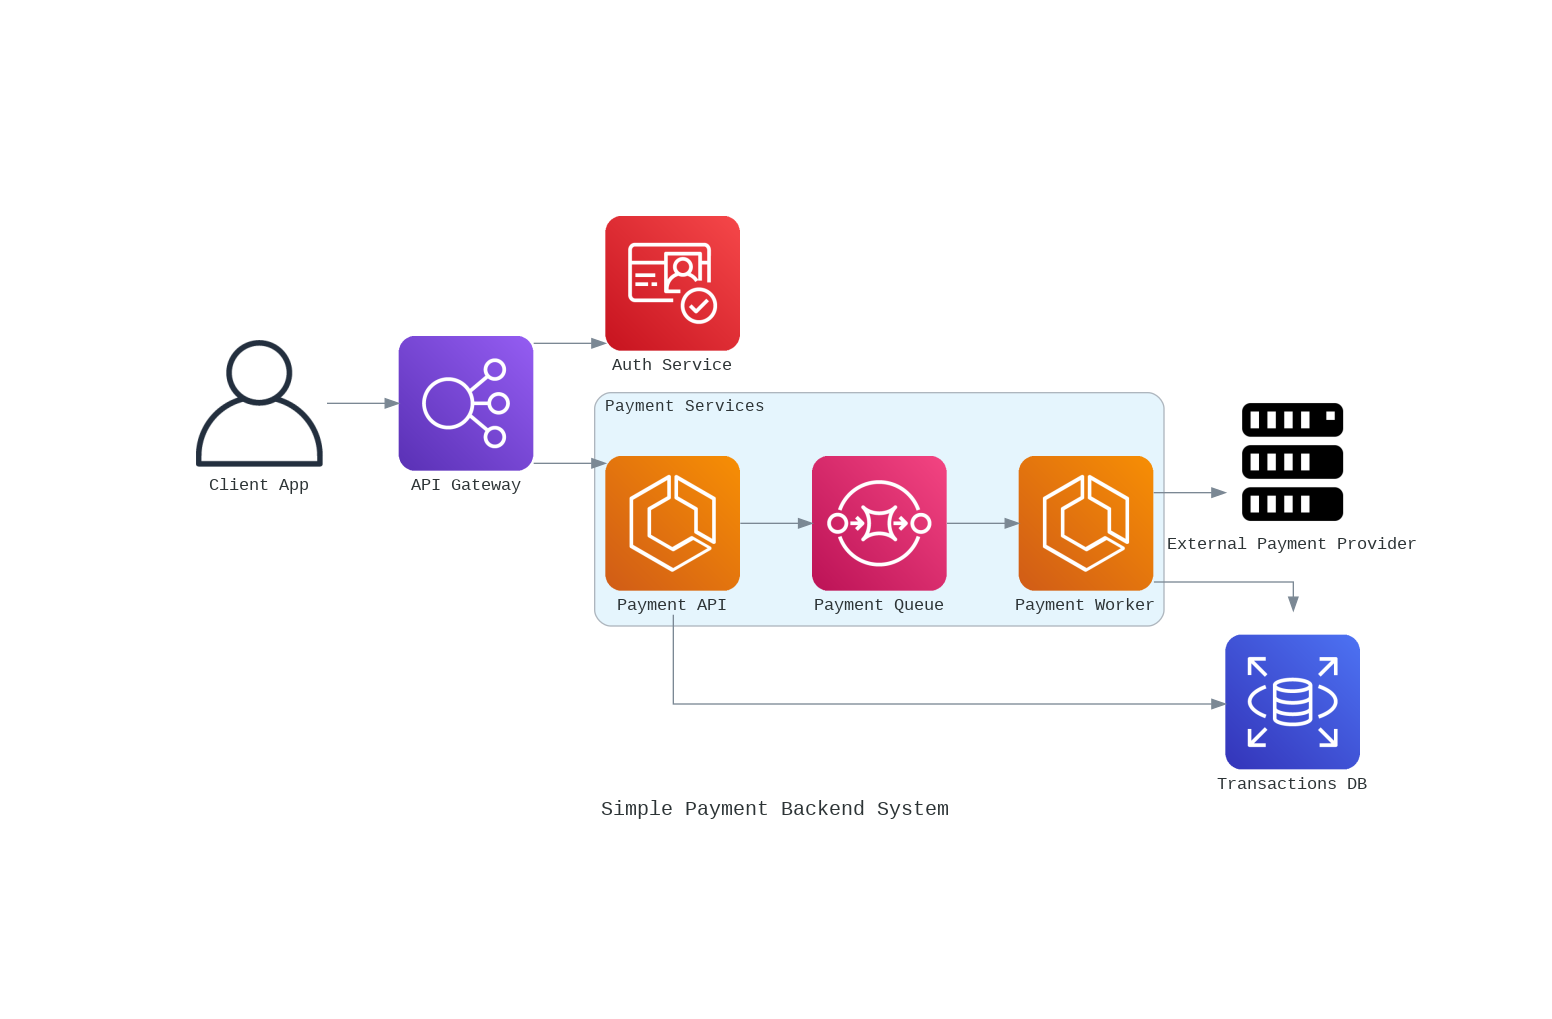

In [11]:
from diagrams import Diagram, Cluster
from diagrams.aws.compute import ECS
from diagrams.aws.database import RDS
from diagrams.aws.integration import SQS
from diagrams.aws.network import ELB
from diagrams.aws.security import Cognito
from diagrams.onprem.client import User
from diagrams.onprem.compute import Server

with Diagram("Simple Payment Backend System", show=False):
    user = User("Client App")
    api_gateway = ELB("API Gateway")
    auth = Cognito("Auth Service")

    with Cluster("Payment Services"):
        payment_service = ECS("Payment API")
        queue = SQS("Payment Queue")
        worker = ECS("Payment Worker")

    db = RDS("Transactions DB")
    payment_provider = Server("External Payment Provider")

    user >> api_gateway
    api_gateway >> auth
    api_gateway >> payment_service
    payment_service >> queue
    queue >> worker
    worker >> payment_provider
    worker >> db
    payment_service >> db

# ---- Add these lines to display in Colab ----
from IPython.display import Image, display
display(Image("simple_payment_backend_system.png"))